# 0.1 Descarga NDVI (Sentinel-2 vía Google Earth Engine)

Réplica en Python del script original de GEE Code Editor usado para Peñalolén:
composite **mediano** de Sentinel-2 SR Harmonized del verano, con máscara de nubes
QA60 (bits 10-11), NDVI = (B8 − B4) / (B8 + B4), 10 m de resolución.

Diferencias con el script original:
- El AOI ya no es un asset subido a GEE — se pasa directo desde `aoi_{zona}.gpkg` (nb 0)
- La descarga es directa a disco (`geemap.download_ee_image`), sin export a Drive

**Prerrequisitos:**
```
pip install earthengine-api geemap
```
Primera vez: ejecutar `ee.Authenticate()` (abre navegador, una sola vez por máquina).

**Entrada:** `data/raw/aoi_{zona}.gpkg` · **Salida:** `data/raw/ndvi_{zona}.tif`

---

In [7]:
import os
import sys
import importlib.util
from pathlib import Path

# ── Fix PROJ (conflicto conda + pip en Windows) ───────────────────────────────
# El rasterio/pyproj de pip trae PROJ nuevo, pero el entorno conda define
# PROJ_LIB apuntando a la proj.db antigua del entorno → CRSError al escribir.
# Redirigimos PROJ a los datos que vienen dentro del paquete pip.
for _pkg, _rel in (('rasterio', 'proj_data'), ('pyproj', 'proj_dir/share/proj')):
    _spec = importlib.util.find_spec(_pkg)
    if _spec is not None:
        _cand = Path(_spec.origin).parent / _rel
        if (_cand / 'proj.db').exists():
            os.environ['PROJ_LIB']  = str(_cand)
            os.environ['PROJ_DATA'] = str(_cand)
            print(f'PROJ_DATA -> {_cand}')
            break

sys.path.insert(0, str(Path('..').resolve()))
from config import (ZONA, FP_AOI, FP_NDVI, CRS_GEO, CRS_PROJ,
                    NDVI_START, NDVI_END, NDVI_MAX_CLOUD, NDVI_SCALE, EE_PROJECT)

import geopandas as gpd
import ee
import geemap

# ee.Authenticate()   # ← solo la primera vez en esta máquina (ya hecho)
ee.Initialize(project=EE_PROJECT)
print(f'GEE inicializado | zona: {ZONA} | periodo: {NDVI_START} → {NDVI_END}')

PROJ_DATA -> C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\rasterio\proj_data
GEE inicializado | zona: suroriente | periodo: 2024-10-01 → 2025-03-31


## 1. AOI local → geometría GEE

In [8]:
aoi = gpd.read_file(FP_AOI, layer='aoi').to_crs(CRS_GEO)
geom = aoi.geometry.iloc[0]

# Simplificar levemente para no exceder el límite de vértices de la API (~1° ≈ 111 km)
geom_simple = geom.simplify(0.0002, preserve_topology=True)
geom_ee = ee.Geometry(geom_simple.__geo_interface__)

print(f'Geometría: {geom.geom_type} → {geom_simple.geom_type} '
      f'(vértices reducidos para la API)')
print(f'Bounds: {aoi.total_bounds.round(4)}')

Geometría: Polygon → Polygon (vértices reducidos para la API)
Bounds: [-70.6316 -33.5702 -70.4371 -33.4289]


## 2. Composite Sentinel-2 con máscara de nubes (idéntico al script GEE)

In [9]:
def mask_s2_clouds(image):
    """Máscara QA60: bit 10 = nubes opacas, bit 11 = cirrus."""
    qa = image.select('QA60')
    cloud_bit  = 1 << 10
    cirrus_bit = 1 << 11
    mask = (qa.bitwiseAnd(cloud_bit).eq(0)
            .And(qa.bitwiseAnd(cirrus_bit).eq(0)))
    return (image.updateMask(mask)
                 .divide(10000)
                 .copyProperties(image, ['system:time_start']))

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(geom_ee)
      .filterDate(NDVI_START, NDVI_END)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', NDVI_MAX_CLOUD))
      .map(mask_s2_clouds))

n_imgs = s2.size().getInfo()
print(f'Imágenes en el composite: {n_imgs}')
assert n_imgs > 0, 'Sin imágenes — revisar periodo/filtro de nubes'

composite = s2.median().clip(geom_ee)
ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')

Imágenes en el composite: 62


## 3. Descarga a disco

`geemap.download_ee_image` trocea la descarga automáticamente (no aplica el límite
de 32 MB de `getDownloadURL`), por lo que funciona igual para el piloto que para
Gran Santiago (~800 MB a 10 m). Para zonas grandes puede tardar varios minutos.

In [10]:
geemap.download_ee_image(
    ndvi,
    filename=str(FP_NDVI),
    region=geom_ee,
    scale=NDVI_SCALE,
    crs=CRS_PROJ,      # UTM 19S — mismo CRS métrico del pipeline
)
print(f'NDVI guardado: {FP_NDVI}')

C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geemap\common.py:12263: FutureWarning: 'BaseImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  img = gd.download.BaseImage(image)


  0%|          |0/4 tiles [00:00<?]

NDVI guardado: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\raw\ndvi_suroriente.tif


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geedim\image.py:254: RuntimeWarning: Couldn't find STAC entry for: 'None'.
  return STACClient().get(self.id)


## 4. Verificación rápida

Shape: (1578, 1817) | CRS: EPSG:32719 | res: (10.0, 10.0)
NDVI — min: -0.667  max: 0.909  media: 0.264


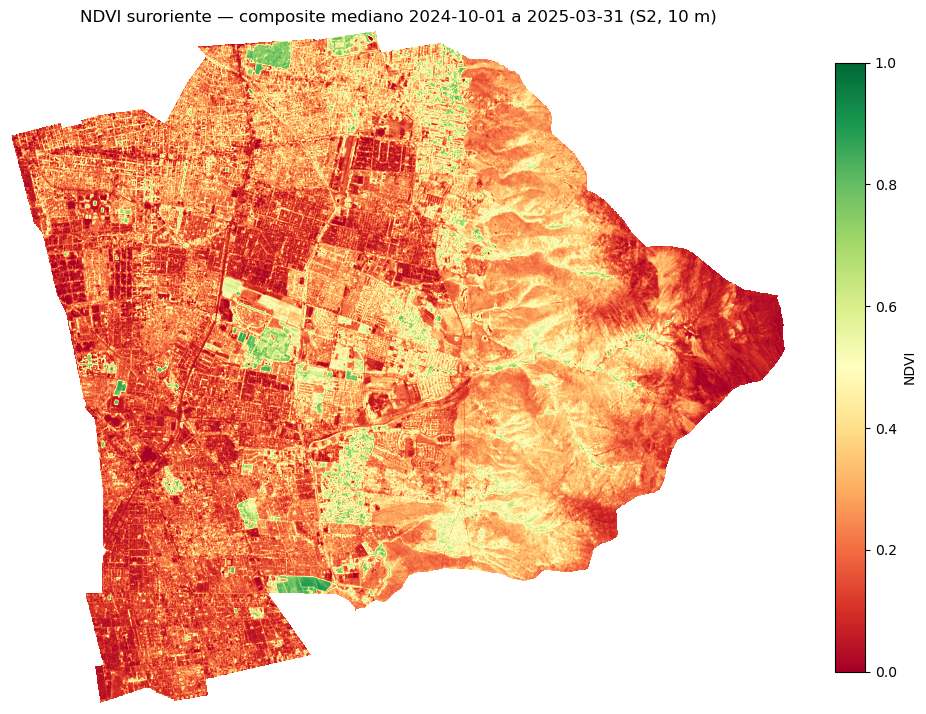

In [11]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(FP_NDVI) as src:
    arr = src.read(1, masked=True)
    print(f'Shape: {arr.shape} | CRS: {src.crs} | res: {src.res}')
    print(f'NDVI — min: {arr.min():.3f}  max: {arr.max():.3f}  media: {arr.mean():.3f}')

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(arr, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.7, label='NDVI')
ax.set_title(f'NDVI {ZONA} — composite mediano {NDVI_START} a {NDVI_END} (S2, 10 m)')
ax.set_axis_off()
plt.tight_layout()
plt.show()